# Raster Math

<div class="page-subtitle">
Extracting Environmental Relationships
</div>

---

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/HendrikWulf/sds210-jb/blob/main/book/12_L10_time-series/06_raster_math.ipynb)

---

```{admonition} Big idea
:class: tip

Once spatial datasets are aligned, mathematical operations allow you to extract environmental relationships, like identifying ecological boundaries across elevations.
```

In previous chapters, you learned how to inspect and visualize multidimensional data cubes. Now we move from inspection to analysis. `xarray` makes raster math incredibly robust because it automatically preserves spatial dimensions and coordinates during computation. This means you no longer have to worry about tracking arbitrary NumPy arrays. 

**Applied Scenario**
To demonstrate this, we will combine a Landsat 9 optical image (7 bands) and a Copernicus Digital Elevation Model (DEM) over a mountainous region in New Zealand. Our goal is to derive two major ecological boundaries:
1. **The Treeline:** The elevation where vegetation sharply decreases.
2. **The Snowline:** The elevation where snow cover sharply increases.

---

## 1. Preparing the Data Cube

Before doing any math, we need readable, perfectly aligned variables. Satellite data often loads with arbitrary indices (like `Band 1` or `Band 2`). We want to extract exactly what we need, name the variables by their physical wavelength regions, and merge the optical and elevation data into a single master `Dataset`.

In [ ]:
# !pip install rioxarray
import xarray as xr
import rioxarray

# Load the DEM and squeeze out the empty 'band' dimension so it is purely 2D
da_dem = xr.open_dataarray(
    "data/Copernicus_DEM_NZ_subset.tif", engine="rasterio"
).squeeze(drop=True)
# Explicitly drop the 'band' coordinate from da_dem if it exists, to avoid conflicts during merge
da_dem = da_dem.drop_vars("band", errors="ignore")

# Load the Landsat 9 multispectral image
da_landsat = xr.open_dataarray(
    "data/LC09_L1TP_075090_20230224_20230308_02_T1_subset.tif", engine="rasterio"
)

# Merge the selected bands and the DEM into a single, aligned Dataset
ds = xr.Dataset(
    {
        "elevation": da_dem,
        "Green": da_landsat.sel(band=2).drop_vars("band", errors="ignore"),
        "Red": da_landsat.sel(band=3).drop_vars("band", errors="ignore"),
        "NIR": da_landsat.sel(band=4).drop_vars("band", errors="ignore"),
        "SWIR1": da_landsat.sel(band=5).drop_vars("band", errors="ignore"),
    }
)

# Drop the arbitrary 'band' coordinate since we safely named them
ds = ds.drop_vars("band", errors="ignore")
print(ds)

<xarray.Dataset> Size: 88MB
Dimensions:      (x: 2170, y: 2038)
Coordinates:
  * x            (x) float64 17kB 3.997e+05 3.997e+05 ... 4.647e+05 4.647e+05
  * y            (y) float64 16kB 5.209e+06 5.209e+06 ... 5.148e+06 5.148e+06
    spatial_ref  int64 8B 0
Data variables:
    elevation    (y, x) float32 18MB ...
    Green        (y, x) float32 18MB ...
    Red          (y, x) float32 18MB ...
    NIR          (y, x) float32 18MB ...
    SWIR1        (y, x) float32 18MB ...


Because both GeoTIFFs share the exact same spatial grid and Coordinate Reference System, `xarray` effortlessly binds them together. You now have a clean, multidimensional workspace.

### Visualizing the inputs

As we learned in the previous chapter, you should always verify your data visually before analyzing it. We will plot a **False Color Composite** combining the SWIR1, NIR, and Red bands. This specific band combination is excellent for environmental analysis because it cuts through atmospheric haze, highlights healthy vegetation in vivid green, and makes snow and ice pop in bright cyan.

Alongside it, we will use matplotlib's `LightSource` tool to generate a shaded relief map (hillshade) from our elevation data to understand the rugged topography.

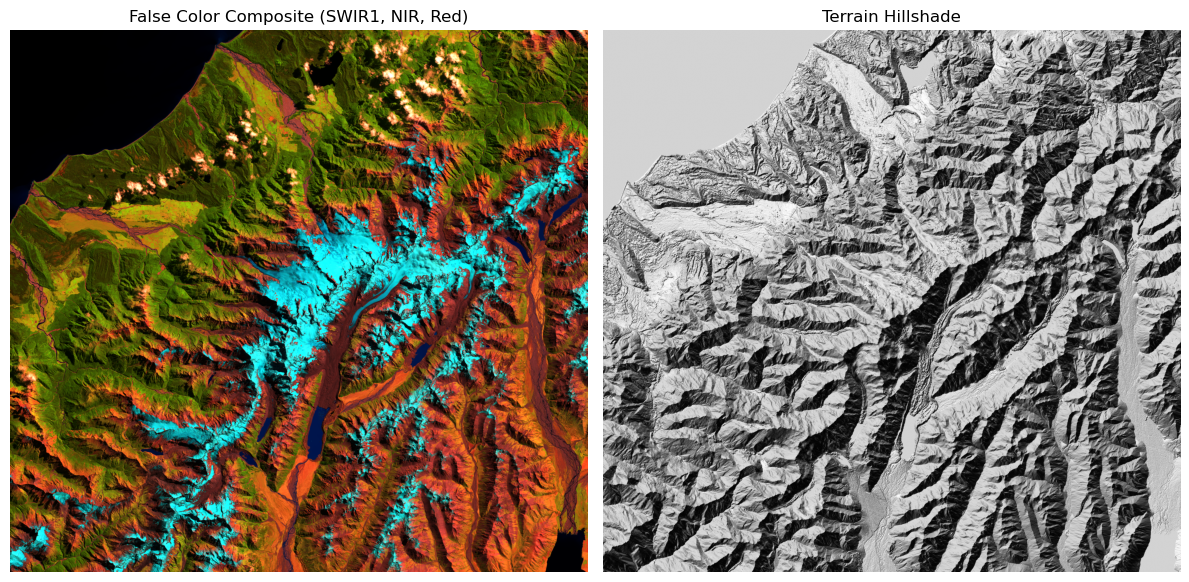

In [19]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LightSource

# Create subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))


# 1. False Color Image (SWIR1, NIR, Red)
def norm_bright(da):
    """Normalize bands and brighten by clipping the top 2% of extreme values."""
    data = da.values
    vmin, vmax = np.percentile(data, [2, 98])
    return np.clip((data - vmin) / (vmax - vmin), 0, 1)


# Stack the normalized bands into a 3D array for RGB plotting
fcc = np.stack(
    [norm_bright(ds.SWIR1), norm_bright(ds.NIR), norm_bright(ds.Red)], axis=-1
)

ax1.imshow(fcc)
ax1.set_title("False Color Composite (SWIR1, NIR, Red)")
ax1.axis("off")

# 2. Hillshade using LightSource
ls = LightSource(azdeg=315, altdeg=45)
hillshade = ls.hillshade(ds.elevation.values, vert_exag=1)

ax2.imshow(hillshade, cmap="gray")
ax2.set_title("Terrain Hillshade")
ax2.axis("off")

plt.tight_layout()
plt.show()

<div class="figure-caption-like">
A side by side comparison of our input variables. The False Color Composite clearly highlights vegetation and snow gradients, while the hillshade verifies the corresponding mountain topography.
</div>

---

## 2. Arithmetic

With our variables properly named, deriving new spatial layers reads exactly like standard mathematical formulas. `xarray` will automatically broadcast the calculation across all pixels simultaneously. It also gracefully handles common raster math issues—such as division by zero over dark water bodies—by silently inserting `NaN` (Not a Number) values without crashing your script.

Let us calculate the Normalized Difference Vegetation Index (NDVI) to quantify tree cover across the landscape.

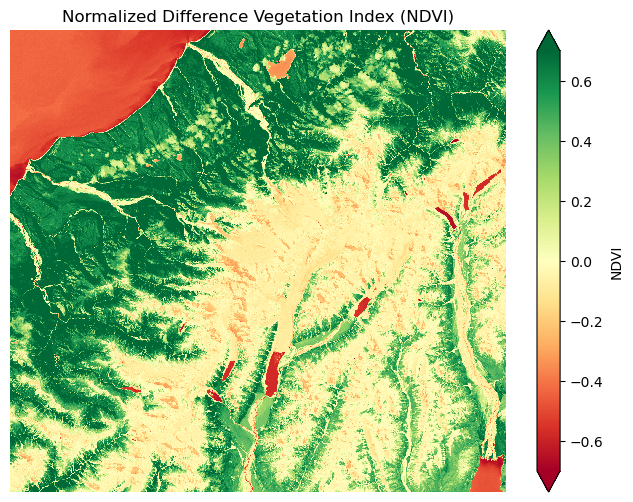

In [20]:
# Calculate NDVI: (NIR - Red) / (NIR + Red)
ds["NDVI"] = (ds.NIR - ds.Red) / (ds.NIR + ds.Red)

# Plot the result with fixed color limits to enhance contrast
ds.NDVI.plot(
    cmap="RdYlGn",
    vmin=-0.7,
    vmax=0.7,
    robust=False,
    size=6,
    cbar_kwargs={"label": "NDVI"},
)

import matplotlib.pyplot as plt

plt.title("Normalized Difference Vegetation Index (NDVI)")
plt.axis("off")
plt.show()

<div class="figure-caption-like">
The computed NDVI layer. Because we assigned the calculation directly back to our Dataset container (ds["NDVI"]), the new derived variable is instantly available and perfectly aligned alongside our elevation data.
</div>

---

## 3. Conditional Masking

Environmental data is naturally messy. Vegetation indices can be heavily skewed by water bodies, dark topographic shadows, or barren rock. To find an accurate treeline, we only want to analyze pixels that definitively contain healthy vegetation. 

We can use the `.where()` method to filter our dataset based on a logical condition. Any pixel that fails the condition is replaced with `NaN` (Not a Number), ensuring it will be safely ignored in all future calculations.

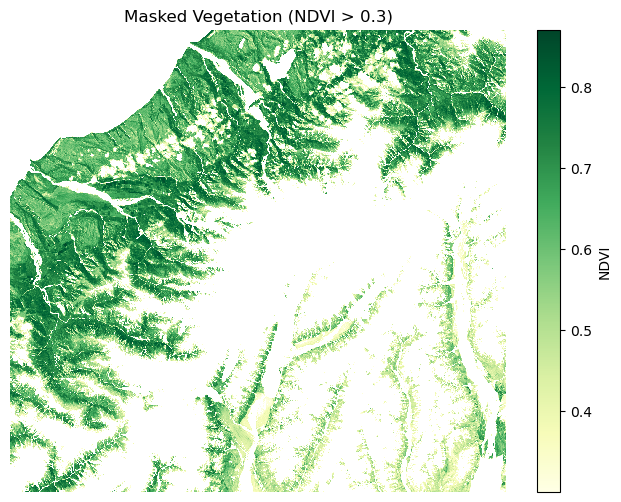

In [21]:
# Mask out non-vegetated pixels (0.3 is a standard threshold for healthy canopy)
ds["NDVI_masked"] = ds.NDVI.where(ds.NDVI > 0.3)

# Visualize the masked layer
import matplotlib.pyplot as plt

ds.NDVI_masked.plot(cmap="YlGn", size=6, cbar_kwargs={"label": "NDVI"})

plt.title("Masked Vegetation (NDVI > 0.3)")
plt.axis("off")
plt.show()

<div class="figure-caption-like">
The masked NDVI layer. The white areas represent pixels that failed our condition (NDVI > 0.3) and have been safely converted to NaN.
</div>

---

## 4. Zonal Statistics

How do we relate a 2D vegetation map to a 2D elevation map? We use grouping. `xarray` provides the `.groupby_bins()` method, which allows you to aggregate one variable based on the values of another perfectly aligned variable.

Here, we will group our masked NDVI data by the underlying elevation data, splitting the terrain into 50-meter vertical bins. Rather than just calculating the average vegetation, we will also count how many pixels fall into each bin so we can verify our sample sizes later.

In [ ]:
import numpy as np
import xarray as xr

# Define vertical bins from 0m to 2500m in 50m increments
elev_bins = np.arange(0, 2500, 50)

# Create the grouped object
grouped = ds.NDVI_masked.groupby_bins(ds.elevation, bins=elev_bins)

# Calculate both mean and count, and merge them into a single Dataset
ds_profile = xr.merge(
    [grouped.mean().rename("ndvi_mean"), grouped.count().rename("ndvi_count")]
)

ds_profile

<xarray.Dataset> Size: 1kB
Dimensions:         (elevation_bins: 49)
Coordinates:
  * elevation_bins  (elevation_bins) interval[int64, right] 784B (0, 50] ... ...
    spatial_ref     int64 8B 0
Data variables:
    ndvi_mean       (elevation_bins) float32 196B 0.6461 0.6725 ... nan nan
    ndvi_count      (elevation_bins) int64 392B 150594 114785 118070 ... 1 0 0
Attributes:
    AREA_OR_POINT:  Area
    long_name:      ('Blue', 'Green', 'Red', 'NIR', 'SWIR1', 'SWIR2', 'TIR1')

This operation is incredibly powerful. We have just collapsed our massive 2D rasters into a clean 1D ecological gradient. The `ndvi_count` variable tells us how many pixels went into each average, which will be critical for quality control in the next step.

### Extracting bin centers

By default, `.groupby_bins()` labels the new coordinate using Pandas interval objects (e.g., `(100, 150]`). While technically accurate, interval objects cannot be easily plotted on a graph, nor can we calculate their mathematical derivatives. 

To fix this, we need to extract the exact midpoint of each bin using the underlying Pandas index. We will use a defensive programming approach to do this safely.

In [ ]:
# Extract the underlying Pandas index
idx = ds_profile.elevation_bins.to_index()

# Check if the index still contains interval objects (which have a '.mid' attribute)
if hasattr(idx, "mid"):
    # Convert interval coordinates to numeric midpoints
    ds_profile.coords["elevation_bins"] = idx.mid
else:
    print("Note: Elevation bins are already numeric midpoints.")

# Display the cleaned profile data
ds_profile

<xarray.Dataset> Size: 988B
Dimensions:         (elevation_bins: 49)
Coordinates:
  * elevation_bins  (elevation_bins) float64 392B 25.0 75.0 ... 2.425e+03
    spatial_ref     int64 8B 0
Data variables:
    ndvi_mean       (elevation_bins) float32 196B 0.6461 0.6725 ... nan nan
    ndvi_count      (elevation_bins) int64 392B 150594 114785 118070 ... 1 0 0
Attributes:
    AREA_OR_POINT:  Area
    long_name:      ('Blue', 'Green', 'Red', 'NIR', 'SWIR1', 'SWIR2', 'TIR1')

**Why the `if` statement?**
In an interactive Jupyter environment, it is common to run the same cell multiple times. If you run this cell a second time, the intervals have already been converted into standard numbers, which do not have a `.mid` attribute. This defensive check prevents your script from crashing, allowing you to re-run the analysis smoothly.

---

## 5. Finding the Treeline

Before we extract our final ecological boundary, we must address a common pitfall in spatial statistics: **sample size**. 

Elevation bins near the very peak of a mountain might only contain a handful of pixels. Calculating an average NDVI from just five pixels produces noisy, unreliable data that can easily trick our algorithms. To fix this, we filter out any elevation bins that do not have a statistically significant number of pixels.

Once the noisy peaks are removed, we can confidently identify the treeline. In this approach, we define the treeline as the elevation where the healthy vegetation canopy finally bottoms out to its minimum value.

```{admonition} Is that approach really scientific?
:class: warning

While identifying the treeline using minimum NDVI values or steepest derivatives makes for a great practical coding example, this approach is highly simplistic and not scientifically rigorous. Real-world ecological modeling requires accounting for variables like slope, aspect, microclimates, and species-specific thresholds. The primary goal here is pedagogical: to demonstrate the mechanics of applying raster math, filtering, and 1D data aggregation methods in Python.
```

Refined Treeline Elevation (Min NDVI): 1975.0 meters


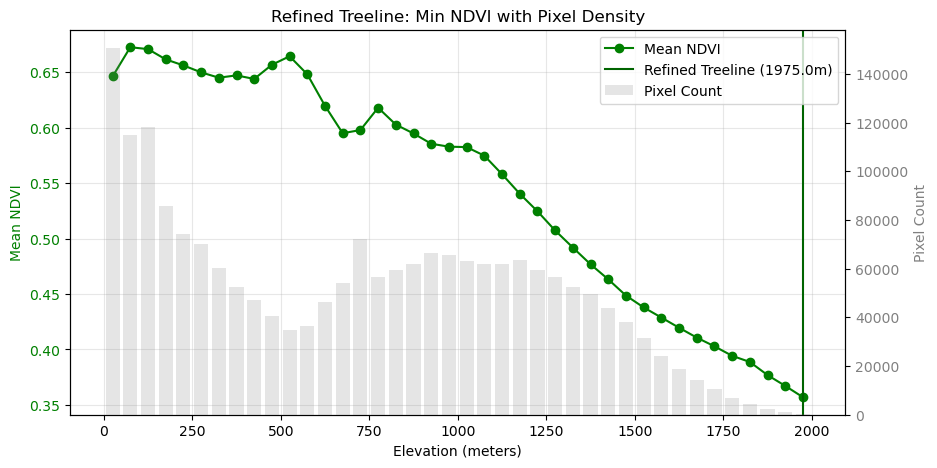

In [ ]:
import matplotlib.pyplot as plt

# 1. Filter out bins with fewer than 100 pixels
ds_filtered = ds_profile.where(ds_profile.ndvi_count >= 100, drop=True)

# 2. Define treeline as the elevation with the minimum NDVI value
refined_treeline = ds_filtered.ndvi_mean.idxmin().values

print(f"Refined Treeline Elevation (Min NDVI): {refined_treeline} meters")

# 3. Visualize with Dual Y-Axis
fig, ax1 = plt.subplots(figsize=(10, 5))

# Primary Axis: Mean NDVI
ax1.plot(
    ds_filtered.elevation_bins,
    ds_filtered.ndvi_mean,
    marker="o",
    label="Mean NDVI",
    color="green",
)
ax1.axvline(
    refined_treeline,
    color="darkgreen",
    linestyle="-",
    label=f"Refined Treeline ({refined_treeline}m)",
)
ax1.set_xlabel("Elevation (meters)")
ax1.set_ylabel("Mean NDVI", color="green")
ax1.tick_params(axis="y", labelcolor="green")

# Secondary Axis: Pixel Count
ax2 = ax1.twinx()
ax2.bar(
    ds_filtered.elevation_bins,
    ds_filtered.ndvi_count,
    alpha=0.2,
    color="gray",
    width=40,
    label="Pixel Count",
)
ax2.set_ylabel("Pixel Count", color="gray")
ax2.tick_params(axis="y", labelcolor="gray")

plt.title("Refined Treeline: Min NDVI with Pixel Density")
# Use ax1.legend to keep it inside the plot area
fig.legend(loc="upper right", bbox_to_anchor=(0.9, 0.88))
ax1.grid(True, alpha=0.3)
plt.show()

<div class="figure-caption-like">
A dual-axis plot revealing the relationship between the vegetation gradient (green line) and the underlying terrain distribution (gray bars). By filtering out the low-pixel-count bins at the highest elevations, we prevent noisy data from skewing our objective treeline detection.
</div>

---

## 6. Exercise: Calculating the Snowline

Now it is your turn to apply this raster math and filtering workflow. Using the exact same dataset, your task is to identify the **snowline**. 

**Your task:**
1. **Calculate and Mask NDSI:** Create a new variable for the Normalized Difference Snow Index using the formula `(Green - SWIR1) / (Green + SWIR1)`. Mask out invalid pixels by keeping only areas where NDSI > 0.4 and NIR > 0.1 (this secondary NIR condition helps remove water and deep shadows).
2. **Bin and Merge:** Group your masked NDSI layer by the elevation bins. This time, calculate both the `.mean()` and the `.count()`, and merge them into a single profile dataset. Remember to extract the numeric bin centers.
3. **Filter by Pixel Density:** To avoid noisy data at the edges of the snowpack, calculate a dynamic threshold: 50% of the maximum pixel count across all bins. Filter your profile to keep only the bins that meet or exceed this threshold.
4. **Find the Snowline:** Define the snowline as the elevation with the minimum average NDSI within your filtered, valid data. Print this calculated elevation.
5. **Dual-Axis Visualization:** Generate a plot with two y-axes. Show the mean NDSI on the primary axis (distinguishing valid vs. low-density bins visually) and the pixel counts as a bar chart on the secondary axis. Highlight the exact elevation of the snowline with a vertical line.

**Starter code:**

In [26]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Calculate NDSI and apply the dual-condition mask
# ...

# 2. Group by elevation, calculate mean and count, and handle bin midpoints
# ...

# 3. Identify valid range based on a 50% max pixel threshold
# ...

# 4. Find the snowline (minimum NDSI within the valid range)
# ...

# 5. Dual-Axis Visualization
# ...

````{admonition} Sample solution
:class: dropdown

```{code-cell} python
import matplotlib.pyplot as plt
import numpy as np

# 1. Calculate NDSI and apply mask
ds["NDSI"] = (ds.Green - ds.SWIR1) / (ds.Green + ds.SWIR1)
ds["NDSI_masked"] = ds.NDSI.where((ds.NDSI > 0.4) & (ds.NIR > 0.1))

# 2. Group by elevation and calculate mean and count
grouped_snow = ds.NDSI_masked.groupby_bins(ds.elevation, bins=elev_bins)
ds_snow_profile = xr.merge([
    grouped_snow.mean().rename("ndsi_mean"),
    grouped_snow.count().rename("ndsi_count")
])

# Handle bin midpoints
idx_snow = ds_snow_profile.elevation_bins.to_index()
if hasattr(idx_snow, 'mid'):
    ds_snow_profile.coords['elevation_bins'] = idx_snow.mid

# 3. Identify valid range based on 50% max pixel threshold
snow_pixel_threshold = 0.5 * ds_snow_profile.ndsi_count.max().values
mask_valid = ds_snow_profile.ndsi_count >= snow_pixel_threshold
ds_snow_filtered = ds_snow_profile.where(mask_valid, drop=True)

# 4. Find snowline
snowline_elev = ds_snow_filtered.ndsi_mean.idxmin().values
print(f"Snow Pixel Threshold (50% of max): {snow_pixel_threshold:.1f}")
print(f"Calculated Snowline Elevation (Min NDSI): {snowline_elev} meters")

# 5. Dual-Axis Visualization
fig, ax1 = plt.subplots(figsize=(10, 5))
ax2 = ax1.twinx()

# NDSI Lines (Primary Axis)
ax1.plot(ds_snow_profile.elevation_bins, ds_snow_profile.ndsi_mean, color='lightgrey', linestyle='--', label="Low Density")
ax1.plot(ds_snow_filtered.elevation_bins, ds_snow_filtered.ndsi_mean, marker="o", color='blue', label="Valid NDSI")
ax1.axvline(snowline_elev, color="darkblue", linestyle="--", label=f"Snowline ({snowline_elev}m)")

# Pixel Count Bars (Secondary Axis)
colors = ["blue" if v else "grey" for v in mask_valid.values]
ax2.bar(ds_snow_profile.elevation_bins, ds_snow_profile.ndsi_count, width=40, color=colors, alpha=0.4, label="Pixel Count")

# Formatting
ax1.set_xlabel("Elevation (m)")
ax1.set_ylabel("Mean NDSI", color='blue')
ax2.set_ylabel("Pixel Count", color='gray')
plt.title("Complete Snowline Analysis and Visualization")
fig.legend(loc="upper left", bbox_to_anchor=(0.15, 0.88))
ax1.grid(True, alpha=0.3)
plt.show()
```
:::{figure} images/11_ex_snowline_analysis.png
:alt: A dual-axis plot showing mean NDSI on the primary axis and pixel count on the secondary axis, with a vertical line indicating the snowline.
:width: 700px
:align: center

*A complete dual-axis analysis of the snowline. By filtering out elevation bins with low pixel counts (shown in grey), we isolate the core snowpack. The snowline is identified at the lower elevation boundary of this valid data.*
:::
````

---

## 7. Summary

By aligning variables inside an `xarray` dataset, raster math transitions from tedious band management into robust, intuitive analysis. 

* **Direct Arithmetic:** Raster math in `xarray` behaves exactly like basic arithmetic, automatically broadcasting operations across millions of pixels while keeping coordinate labels intact.
* **Cleaning Data:** Functions like `.where()` are critical for applying logical thresholds and masking out invalid pixels before deriving environmental statistics.
* **Zonal Analysis:** The true power of multidimensional alignment is unlocked when we use one variable to group or slice another. By binning vegetation and snow against elevation, we transformed millions of raw pixels into 1D ecological gradients.
* **Statistical Filtering:** Real-world environmental data is inherently noisy. Filtering your aggregated results by pixel density (sample size) ensures that your calculated boundaries are driven by robust data, rather than random anomalies at the extreme edges of the landscape.